
F_R1s(r) =
+33.7974 * exp(-12.6074 r)
+17.9101 * exp(-7.4101 r)
-20.3570 * r^2 * exp(-23.2475 r)
+93.3776 * r * exp(-10.7416 r)
+0.0688 * r * exp(-3.7543 r)
+0.0038 * r * exp(-2.5009 r)
+0.0008 * r * exp(-1.8577 r)

F_R2s(r) =
-5.2365 * exp(-12.6074 r)
+17.2042 * exp(-7.4101 r)
-6.9985 * r^2 * exp(-23.2475 r)
-27.7090 * r * exp(-10.7416 r)
-11.3191 * r * exp(-3.7543 r)
-5.9009 * r * exp(-2.5009 r)
-1.2989 * r * exp(-1.8577 r)

F_R2p(r) =
+2.2678 * r * exp(-11.0134 r)
+8.4267 * r * exp(-4.9962 r)
+6.8926 * r * exp(-3.1540 r)
+2.4985 * r * exp(-1.9722 r)
+0.5646 * r * exp(-1.3632 r)
Norm 1s = 1.000000248932188
Norm 2s = 1.0000002785183661
Norm 2p = 0.9999991341606669
           Q  J_1s_one_electron  J_2s_one_electron  J_2p_one_electron  \
0       0.00       1.003004e-01       5.077122e-01       3.068598e-01   
1       0.05       1.002893e-01       5.063775e-01       3.068565e-01   
2       0.10       1.002561e-01       5.023995e-01       3.068272e-01   
3       0.15       1.002008e-01  

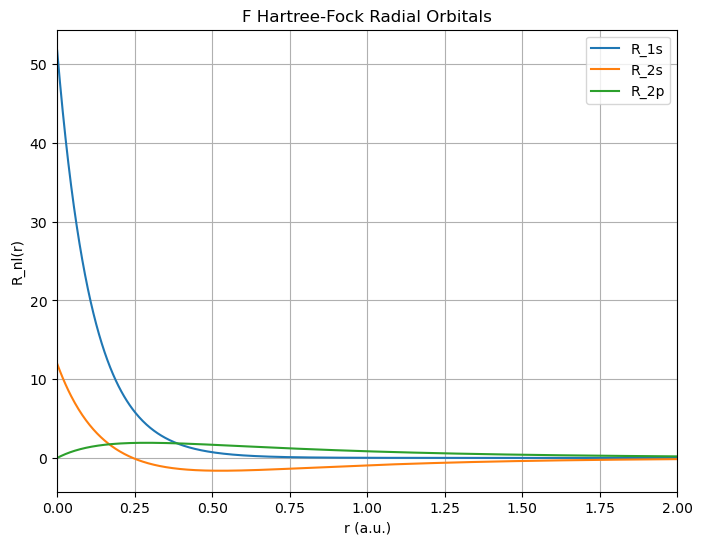

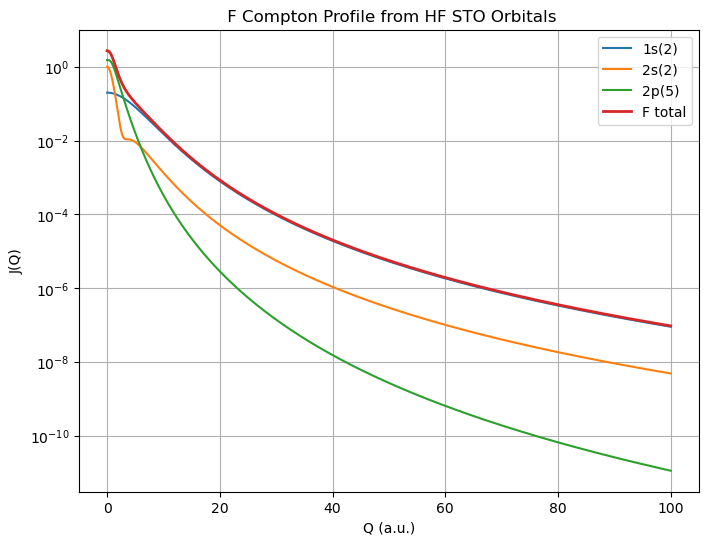

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid

# =====================================================
# Neon Hartree-Fock STO data
# Ne: 1s2 2s2 2p6
# Z = 10
# Format: (n_j, Z_j, C_j)
# =====================================================

# =====================================================
# Fluorine Hartree-Fock STO data
# F: 1s2 2s2 2p5
# Z = 9
# Ground term: 2P
# Format: (n_j, Z_j, C_j)
# =====================================================

# -------------------------
# F 1s orbital
# -------------------------
fluorine_1s = [
    (1, 12.6074,  0.377498),
    (1,  7.4101,  0.443947),
    (3, 23.2475, -0.000797),

    (2, 10.7416,  0.213846),
    (2,  3.7543,  0.002183),
    (2,  2.5009,  0.000335),
    (2,  1.8577,  0.000147),
]

# -------------------------
# F 2s orbital
# -------------------------
fluorine_2s = [
    (1, 12.6074, -0.058489),
    (1,  7.4101,  0.426450),
    (3, 23.2475, -0.000274),

    (2, 10.7416, -0.063457),
    (2,  3.7543, -0.358939),
    (2,  2.5009, -0.516660),
    (2,  1.8577, -0.239143),
]

# -------------------------
# F 2p orbital
# -------------------------
fluorine_2p = [
    (2, 11.0134, 0.004879),
    (2,  4.9962, 0.130794),
    (2,  3.1540, 0.337876),
    (2,  1.9722, 0.396122),
    (2,  1.3632, 0.225374),
]



# =====================================================
# HF normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================
def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R
# =====================================================
# Grids
# =====================================================

r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 1000.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid

# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================

def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2
        val = np.sqrt(2/np.pi) * np.trapezoid(integrand, r_grid)
        chi.append(val)

    return np.array(chi)

# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================

def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]

    # Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev_integral[::-1]

    # Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)

    return I, J_Q

# =====================================================
# Build Fluorine radial orbitals
# =====================================================
def print_R_formula(coeffs, name):
    print(f"\n{name}(r) =")

    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        A = C * N

        if n == 1:
            print(f"{A:+.4f} * exp(-{Z:.4f} r)")
        elif n == 2:
            print(f"{A:+.4f} * r * exp(-{Z:.4f} r)")
        elif n == 3:
            print(f"{A:+.4f} * r^2 * exp(-{Z:.4f} r)")
        elif n == 4:
            print(f"{A:+.4f} * r^3 * exp(-{Z:.4f} r)")
            
R1s = R_nl(r, fluorine_1s)
R2s = R_nl(r, fluorine_2s)
R2p = R_nl(r, fluorine_2p)

print_R_formula(fluorine_1s, "F_R1s")
print_R_formula(fluorine_2s, "F_R2s")
print_R_formula(fluorine_2p, "F_R2p")

# =====================================================
# Momentum-space wavefunctions
# =====================================================

chi_1s = chi_p(p, r, R1s, l=0)
chi_2s = chi_p(p, r, R2s, l=0)
chi_2p = chi_p(p, r, R2p, l=1)


# =====================================================
# Momentum densities and Compton profiles
# =====================================================
I_1s, J_1s = calculate_J(p, chi_1s, Q)
I_2s, J_2s = calculate_J(p, chi_2s, Q)
I_2p, J_2p = calculate_J(p, chi_2p, Q)

print("Norm 1s =", np.trapezoid(I_1s, p))
print("Norm 2s =", np.trapezoid(I_2s, p))
print("Norm 2p =", np.trapezoid(I_2p, p))

# Na: 1s2 2s2 2p6 3s1
J_total = 2*J_1s + 2*J_2s + 5*J_2p   

# =====================================================
# Print and save table
# =====================================================
table = pd.DataFrame({
    "Q": Q,
    "J_1s_one_electron": J_1s,
    "J_2s_one_electron": J_2s,
    "J_2p_one_electron": J_2p,
    "J_total_F": J_total
    })
print(table)
table.to_csv("F_STO_HF_profile.csv", index = False)

# =====================================================
# Plot radial orbitals
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.plot(r, R2s, label="R_2s")
plt.plot(r, R2p, label="R_2p")
plt.xlim(0, 2)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("F Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================
plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, 2*J_2s, label="2s(2)")
plt.plot(Q, 5*J_2p, label="2p(5)")

plt.plot(Q, J_total, label="F total", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title(" F Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()